In [1]:
using Lux, SciMLSensitivity, DifferentialEquations, Zygote, Optimisers, Plots ,OptimizationOptimJL  
using Optimization, OptimizationOptimisers, ComponentArrays, Random, Statistics, Printf, JLD2,DataFrames

Random.seed!(1234)

TaskLocalRNG()

In [2]:
# Hodgkin-Huxley Model Parameters (Global Constants)

const CURRENT_SCALE = 100.0 # <--- THIS IS THE MAGIC NUMBER
# Physical Constants
const Cm = 1.0        # μF/cm^2
const g_Na = 120.0    # mS/cm^2
const g_K = 36.0      # mS/cm^2
const g_L = 0.3       # mS/cm^2
const E_Na = 50.0     # mV
const E_K = -77.0     # mV
const E_L = -54.3870   # mV

-54.387

In [3]:
# Voltage-gated ion channel kinetics (Float64)

α_n(V) = 0.01 * (V + 55.0) / (1.0 - exp(-(V + 55.0) / 10.0))
β_n(V) = 0.125 * exp(-(V + 65.0) / 80.0)

α_m(V) = 0.1 * (V + 40.0) / (1.0 - exp(-(V + 40.0) / 10.0))
β_m(V) = 4.0 * exp(-(V + 65.0) / 18.0)

α_h(V) = 0.07 * exp(-(V + 65.0) / 20.0)
β_h(V) = 1.0 / (1.0 + exp(-(V + 35.0) / 10.0))

# Steady-state & time-constant functions)

m_inf(V) = α_m(V) / (α_m(V) + β_m(V))
h_inf(V) = α_h(V) / (α_h(V) + β_h(V))
n_inf(V) = α_n(V) / (α_n(V) + β_n(V))

tau_n(V) = 1.0 / (α_n(V) + β_n(V))

println("Physics of neural dynamics defined in Float64")

Physics of neural dynamics defined in Float64


In [10]:
Stimulus(t) = (10.0 ≤ t ≤ 11.0) ? 50.0 : 0.0


Stimulus (generic function with 1 method)

In [21]:
s = [Stimulus(i) for i in 0.0:0.5:50.0]

101-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [11]:

# 2D Hodgkin-Huxley reduced model engine
function hodgkin_huxley_reduced!(du, u, p, t)
    V, n = u
    I_ext = Stimulus(t)


    # Known 2D current
    I_Na = g_Na * m_inf(V)^3 * h_inf(V) * (V - E_Na)
    I_K  = g_K  * n^4 * (V - E_K)
    I_L  = g_L * (V - E_L)
    du[1] = (  I_ext - (I_Na + I_K + I_L)   ) / Cm
    du[2] = (n_inf(V) - n) / tau_n(V)
end

# Generate Data
u0_true = [-65.0, n_inf(-65.0)]
tspan = (0.0, 50.0)
prob_true = ODEProblem(hodgkin_huxley_reduced!, u0_true, tspan)
sol_true = solve(prob_true, Rodas5P(), saveat=0.5,reltol=1e-10, abstol=1e-10)

# Extract and structure the training data
data_V = sol_true[1, :]
t_train = sol_true.t
data_n =sol_true[2, :]

# (Optional) Verify data shape and content
df = DataFrame(t=t_train, V=data_V , n = data_n)
println("Generated Training Data:")
display(first(df))


Generated Training Data:


Row,t,V,n
,Float64,Float64,Float64
1,0.0,-65.0,0.317677


In [6]:
using CSV 
CSV.write("data_generated.csv", df)
println("DataFrame saved to data_generation.csv")

DataFrame saved to data_generation.csv


In [19]:
df.t

101-element Vector{Float64}:
  0.0
  0.5
  1.0
  1.5
  2.0
  2.5
  3.0
  3.5
  4.0
  4.5
  5.0
  5.5
  6.0
  ⋮
 44.5
 45.0
 45.5
 46.0
 46.5
 47.0
 47.5
 48.0
 48.5
 49.0
 49.5
 50.0

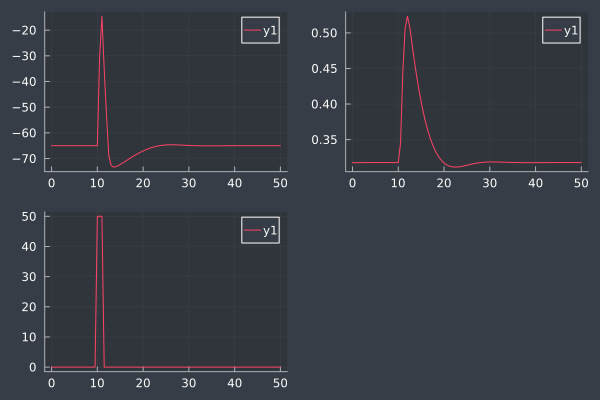

In [22]:
theme(:dark)
p1 = plot(df.t,df.V)
p2 = plot(df.t ,df.n)
p3 = plot(df.t,s)

plot(p1,p2,p3)

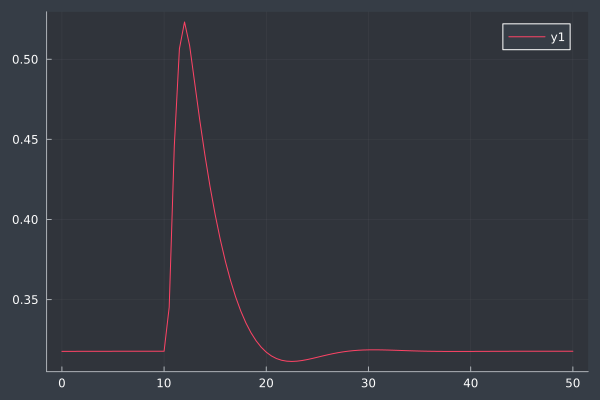

In [23]:
plot(df.t,df.n)

In [10]:
# This is actually voltage data, not time
V = Float64.(df.V)

# Create time vector (assuming 0.1 ms timesteps over 50 ms)
t = Float64.(df.t)
n = Float64.(data_n) # Changed from df.t to data_n, and Float32 to Float64

101-element Vector{Float64}:
 0.3176769140606974
 0.3176782740598987
 0.317681880207079
 0.31768706587058754
 0.31769323762501445
 0.31769988691753087
 0.31770659519347244
 0.31771303368035064
 0.31771895900853264
 0.3177242057883537
 0.3177286771610442
 0.31773233419845126
 0.3177351849370193
 ⋮
 0.31772990828970116
 0.31773651957642063
 0.31774147384478435
 0.3177449044649882
 0.31774698707599514
 0.3177479219539839
 0.317747919143695
 0.3177471863378605
 0.31774591964405263
 0.31774429690102945
 0.3177424733306748
 0.31774057924536914

In [11]:
t

101-element Vector{Float64}:
  0.0
  0.5
  1.0
  1.5
  2.0
  2.5
  3.0
  3.5
  4.0
  4.5
  5.0
  5.5
  6.0
  ⋮
 44.5
 45.0
 45.5
 46.0
 46.5
 47.0
 47.5
 48.0
 48.5
 49.0
 49.5
 50.0

In [12]:
    U = Lux.Chain(
        Lux.Dense(2 => 32, tanh),
        Lux.Dense(32 => 32, tanh),
        Lux.Dense(32 => 1)
        
    ) |> f64

Chain(
    layer_1 = Dense(2 => 32, tanh),               # 96 parameters
    layer_2 = Dense(32 => 32, tanh),              # 1_056 parameters
    layer_3 = Dense(32 => 1),                     # 33 parameters
)         # Total: 1_185 parameters,
          #        plus 0 states.

In [13]:
# Initialize parameters and state
using ComponentArrays
rng = Random.default_rng()
p_init, st = Lux.setup(rng, U)
p_nn= ComponentArray(p_init)  |>f64 # Parameters as a vector for the optimizer

println("Neural network parameters: ", length(p_nn))

Neural network parameters: 1185


## The hybrid UDE

In [14]:


# Corrected UDE function for 2D Hodgkin-Huxley
function hodgkin_huxley_UDE!(du, u, p, t)
    V, n = u  
    # norm_V = (V-V_mean1)/V_std1
    # Neural network predicts sodium current
    Input_V = V/100
    pred = U([V, n], p, st)[1][1]  
    pred_I_Na = pred * 100
    # Known physics: Potassium & Leak currents
    I_K = g_K * (n^4) * (V - E_K)
    I_L = g_L * (V - E_L)
    I_ext = Stimulus(t) 

    # Dynamics for voltage
    du[1] = (I_ext - pred_I_Na - I_K - I_L) / Cm
    
    # Dynamics for potassium activation (known physics)
    du[2] = (n_inf(V) - n) / tau_n(V)
end

println("✅ UDE System Defined.")

✅ UDE System Defined.


In [15]:
# Calculate initial n value from steady-state
u0 = [Float64(V[1]), Float64(n[1])]
tspan = (0.0, 30.0)
prob_nn = ODEProblem(hodgkin_huxley_UDE!,  u0, tspan, p_nn)

ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
Non-trivial mass matrix: false
timespan: (0.0, 30.0)
u0: 2-element Vector{Float64}:
 -65.0
   0.3176769140606974

In [16]:
mask = t .<= 30.0 
t_short = t[mask]

61-element Vector{Float64}:
  0.0
  0.5
  1.0
  1.5
  2.0
  2.5
  3.0
  3.5
  4.0
  4.5
  5.0
  5.5
  6.0
  ⋮
 24.5
 25.0
 25.5
 26.0
 26.5
 27.0
 27.5
 28.0
 28.5
 29.0
 29.5
 30.0

In [17]:

function predict_ude(p)
    _prob = remake(prob_nn, p=p)  # ✅ Uses prob_nn, not prob
    
    sol = solve(_prob, Rodas5(), saveat=t_short,
                abstol=1e-5, reltol=1e-5,
                sensealg=InterpolatingAdjoint(autojacvec=ZygoteVJP()))
end

# ---- Loss function (keep as Float64) ----
function loss(p)
    pred = predict_ude(p)
    if pred.retcode != :Success
        return 1e6
    end
    pred_V = pred[1, :]
   
    loss_val = sum(abs2, pred_V .- V[mask])
    return loss_val
end

println("Objective Functions Defined.")

Objective Functions Defined.


In [18]:

losses=[]
callback = function (p, l)
    push!(losses, l)
    if length(losses) % 50 == 0
        println("Iteration: $(length(losses)) | Loss: $l")
    end
    return false
end

#1 (generic function with 1 method)

In [ ]:
# Define the optimization problem
optf = Optimization.OptimizationFunction((x, p) -> loss(x), Optimization.AutoZygote())
optprob = Optimization.OptimizationProblem(optf, p_nn)

# ==========================================================
# ⚡ PHASE 1: INITIAL ADAMW TRAINING (High Learning Rate)
# ==========================================================
println("\n⚡ TRANSITIONING TO PHASE 1 (INITIAL TRAINING)...")
# println("   Reason: Starting optimization to reach a 'bouncing state'.")

# 1. RUN PHASE 1: High-Learning Rate AdamW
# Maxiters: 5000 (Adjust as needed for initial convergence)
# You can uncomment and modify the AdamW parameters if a specific setup is desired,
# otherwise, a default AdamW with a reasonable learning rate (e.g., 0.01) is used.
res = Optimization.solve(optprob, 
                         OptimizationOptimisers.Adam(0.005), 
                         callback=callback, 
                         maxiters=3000)

println("✅ Phase 1 Complete. Initial Loss: $(res.objective)")

# ==========================================================
# 🛑 RESUME FROM YOUR CURRENT BOUNCING STATE
# ==========================================================
# We assume 'res' holds your current result (Loss ~170)
# We take those parameters and enter Phase 2.

# println("\n🔄 TRANSITIONING TO PHASE 2 (STABILIZATION)...")
# println("   Reason: Loss is oscillating. Reducing LR to 0.001.")


# optprob_phase2 = remake(optprob, u0 = res.u)

# # 2. RUN PHASE 2: Low-Learning Rate AdamW
# # Maxiters: 2000 (Enough to settle)
# res_stable = Optimization.solve(optprob_phase2, 
#                                 OptimizationOptimisers.AdamW(0.01), 
#                                 callback=callback, 
#                                 maxiters=2000)

println("✅ Phase 2 Complete. Loss should be stable (< 1.0).")

# ==========================================================
# 🚀 PHASE 3: L-BFGS POLISHING (The "Science" Phase)
# ==========================================================
# println("\n🚀 TRANSITIONING TO PHASE 3 (PRECISION POLISH)...")
# println("   Reason: Adam cannot find the exact amplitude. Newton method required.")

# # Ensure OptimizationOptimJL is loaded for LBFGS
# using OptimizationOptimJL 

# # 1. Update Problem with Stable Weights
optprob_phase3 = remake(optprob, u0 = res.u)

# 2. RUN PHASE 3: L-BFGS
# Maxiters: 1000 (It will likely stop earlier when converged)
res_final = Optimization.solve(optprob_phase3, 
                               OptimizationOptimJL.BFGS(), 
                               callback=callback, 
                               maxiters=1000)

println("🏆 VICTORY. Final Loss: $(res_final.objective)")

# ==========================================================
# 💾 SAVE THE GOLDEN WEIGHTS
# ==========================================================
using JLD2
save("UDE_Final_Parameters2.jld2", "p", res_final.u)


⚡ TRANSITIONING TO PHASE 1 (INITIAL TRAINING)...
Iteration: 50 | Loss: 12992.437436514027
Iteration: 100 | Loss: 2624.4301633503833
Iteration: 150 | Loss: 2635.7917854141488
Iteration: 200 | Loss: 2560.8351900834773
Iteration: 250 | Loss: 2687.2139550531992
Iteration: 300 | Loss: 2607.7953773648806
Iteration: 350 | Loss: 4663.750432509178
Iteration: 400 | Loss: 2687.267203594996


In [ ]:
using JLD2
save("UDE_Final_Parameters3.jld2", "p", res.u)

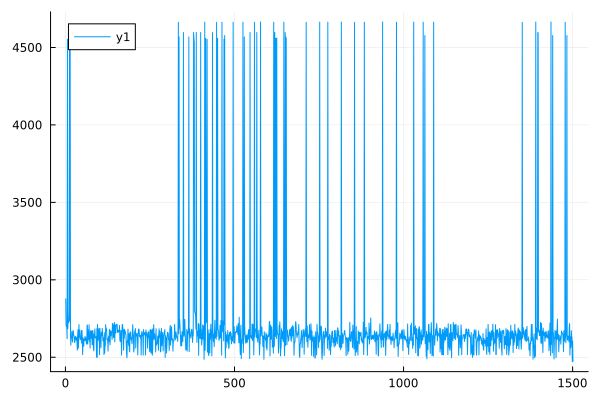

In [ ]:
plot(losses)

In [ ]:
save("UDE_Final_Parameters.jld2", "p", res_final.u)

LoadError: UndefVarError: `res_final` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

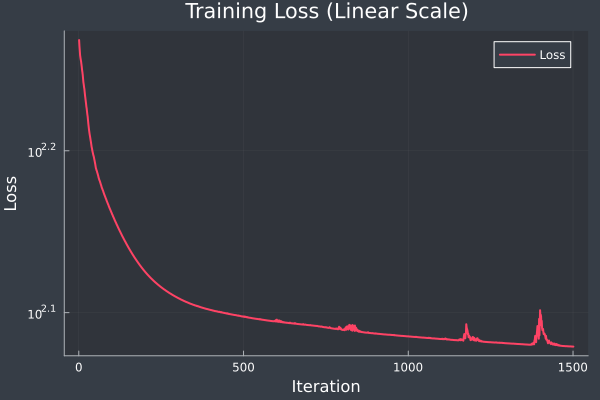

In [ ]:
theme(:dark)
plot(losses,
     xlabel="Iteration",
     ylabel="Loss",
     yaxis=:log,
     title="Training Loss (Linear Scale)",
     label="Loss",
     
     lw=2)